# Import Data

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import datetime
from matplotlib.patches import PathPatch
from matplotlib.path import Path
from scipy.interpolate import interp1d
from collections import defaultdict

In [2]:
scenario="1a"
SCENARIOS = {"0": {"base", "existing"}, 
             "1a": {"base", "existing", "dt_me_lag", "dt_tel_pla", "dt_natkomp_sta", "dt_sta_cia", "dt_cold_sblLac", "dt_lasa_oris" },
             "1b": {"base", "existing"},
             "2a": {"base", "existing"}
}

ACTIVE_SCENARIO = SCENARIOS[scenario]

def load_network_csv(path, index_col):
    df = pd.read_csv(path, sep=";", decimal=",", index_col=index_col)
    return df[df["scenario"].fillna("").apply(lambda s: bool(set(map(str.strip, s.split(","))) & ACTIVE_SCENARIO))]

In [3]:
nodesDf = load_network_csv(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\SimulatedAnnealing\network_with_altitude\double_track_network\nodes_double.csv","node_id")
edgesDf = load_network_csv(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\SimulatedAnnealing\network_with_altitude\double_track_network\edges_double.csv","edge_id")
trip_data = np.load(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\plottingRailML\230215 FBS Fpl 2026-NB-1443983-3.npy", allow_pickle=True).item()
#trip_data = np.load(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\plottingRailML\stamm6.npy", allow_pickle=True).item()
selected_trips_sorted = np.array(list(trip_data.keys()))

In [4]:
def reassign_trip_ids_by_departure(trip_data, first_station="ME", second_station="MAL", save_path=None):
    entries_first = []
    entries_second = []
    entries_other = []

    for old_id, stops in trip_data.items():
        if not stops:
            continue
        first_stop = stops[0][0]
        # prefer explicit departure time at index 2, fallback to index 1
        dep_time = None
        if len(stops[0]) > 2 and stops[0][2] is not None:
            dep_time = stops[0][2]
        elif len(stops[0]) > 1:
            dep_time = stops[0][1]
        else:
            dep_time = pd.NaT

        record = (old_id, dep_time)
        if first_stop == first_station:
            entries_first.append(record)
        elif first_stop == second_station:
            entries_second.append(record)
        else:
            entries_other.append(record)

    # sort by departure time (NaT will go last)
    def _sort_key(x): return (pd.Timestamp.max if pd.isna(x[1]) else x[1])
    entries_first.sort(key=_sort_key)
    entries_second.sort(key=_sort_key)
    entries_other.sort(key=_sort_key)

    ordered_old_ids = [r[0] for r in (entries_first + entries_second + entries_other)]

    new_trip_data = {}
    for new_id, old_id in enumerate(ordered_old_ids, start=1):
        new_trip_data[new_id] = trip_data[old_id]

    if save_path:
        np.save(save_path, new_trip_data, allow_pickle=True)

    return new_trip_data, ordered_old_ids

# Example usage:
# new_trip_data, ordered_old_ids = reassign_trip_ids_by_departure(trip_data, "ME", "MAL", save_path="inputs2/trip_data_reassigned.npy")
# selected_trips_sorted = np.array(list(new_trip_data.keys()))

In [5]:
trip_data, ordered_old_ids=reassign_trip_ids_by_departure(trip_data)

In [6]:
for trip_id in selected_trips_sorted:
    print(f"Trip: {trip_id:<3}"f" leaving {trip_data[trip_id][0][0]:<3}"f" at {trip_data[trip_id][0][1].strftime('%H:%M:%S')}")

Trip: 1   leaving ME  at 16:00:03
Trip: 2   leaving ME  at 17:00:03
Trip: 3   leaving ME  at 18:00:03
Trip: 4   leaving ME  at 19:00:03
Trip: 5   leaving ME  at 20:00:03
Trip: 6   leaving MAL at 16:05:57
Trip: 7   leaving MAL at 17:05:57
Trip: 8   leaving MAL at 18:05:57
Trip: 9   leaving MAL at 19:05:57
Trip: 10  leaving MAL at 20:05:57


## Build routes

In [7]:
def get_routing_node(node, direction):
    """
    For trains towards Malles, use station side nodes when available.
    For trains towards Merano, always use main station nodes.
    """

    if direction == "malles":

        side_node = f"{node}_side"

        if side_node in nodesDf.index:
            return side_node

    return node


# --------------------------------------------------
# Route builder
# --------------------------------------------------

def build_route(nodesDf, edgesDf, start, end):
    successors = defaultdict(list)

    for _, edge in edgesDf.iterrows():
        successors[edge["node_from"]].append(edge["node_to"])
        successors[edge["node_to"]].append(edge["node_from"])
    direction = ("malles" if nodesDf.loc[start, "pk_rel"] <= nodesDf.loc[end, "pk_rel"] else "merano")

    route_start = get_routing_node(start, direction)
    route_end = get_routing_node(end, direction)

    route = [route_start]

    current = route_start
    visited = {route_start}

    while current != route_end:

        pk_current = nodesDf.loc[current, "pk_rel"]

        # only move towards destination
        candidates = [
            n for n in successors[current]
            if (
                nodesDf.loc[n, "pk_rel"] > pk_current
                if direction == "malles"
                else nodesDf.loc[n, "pk_rel"] < pk_current
            )
        ]

        if not candidates:
            raise ValueError(
                f"No valid successor from {current} towards {route_end}"
            )

        # at branching points choose preferred track
        if len(candidates) > 1:

            preferred = [
                n for n in candidates
                if (
                    nodesDf.loc[n, "y"] != 0
                    if direction == "malles"
                    else nodesDf.loc[n, "y"] == 0
                )
            ]

            if preferred:
                candidates = preferred

        next_node = candidates[0]

        if next_node in visited:
            raise ValueError(
                f"Loop detected: {current} -> {next_node}"
            )

        route.append(next_node)
        visited.add(next_node)

        current = next_node

    return route


# --------------------------------------------------
# Build routing dictionary
# --------------------------------------------------

routing_results = {}

for stop_col in ["stop_slow", "stop_fast"]:

    stops = nodesDf.index[(nodesDf[stop_col] == 1) & (nodesDf["y"] == 0)].tolist()

    for start, end in zip(stops[:-1], stops[1:]):

        routing_results[(start, end)] = build_route(nodesDf, edgesDf, start, end)
        routing_results[(end, start)] = build_route(nodesDf, edgesDf, end, start)

# Trajectories

## Functions

In [8]:
def get_s(v,v0, a):
    return 1/2/a*(v*v-v0*v0)

def get_t(v,v0, a):
    return 1/a*np.sqrt(2*a*s(v,v0, a)+v0*v0) - abs(v0) 

#These functions help trasnforming from I to R nodes / paths 
def inodes_from_rnode(rnode):
    return rnode.split("-")[0], rnode.split("-")[1] 

'''def rnode_from_inodes(inode_1, inode_2):
    return inode_1 + "-" + inode_2'''

def rnode_from_inodes(inode_1, inode_2):
    edge1 = f"{inode_1}-{inode_2}"
    edge2 = f"{inode_2}-{inode_1}"

    if edge1 in edgesDf.index:
        return edge1
    elif edge2 in edgesDf.index:
        return edge2
    else:
        raise KeyError(f"No edge between {inode_1} and {inode_2}")

#convert a path of r-nodes to a path of i-nodes for visualizations
def rnode_path(inode_path):
    result = [rnode_from_inodes(inode_path_1, inode_path_2) for (inode_path_1, inode_path_2) in zip(inode_path[:-1],inode_path[1:])]
    
    return result

def get_edge(rnode, edgesDf):
    if rnode in edgesDf.index:
        row = edgesDf.loc[rnode].copy()

        # Direzione come memorizzata nel dataframe
        row["maxspeed"] = row["max_speed_dir_malles"]
        row["gradient"] = row["gradient"]

        return row

    rnode_rev = "-".join(reversed(rnode.split("-")))

    if rnode_rev in edgesDf.index:
        row = edgesDf.loc[rnode_rev].copy()

        # Direzione opposta
        row["maxspeed"] = row["max_speed_dir_merano"]
        row["gradient"] = -row["gradient"]

        return row

    raise KeyError(f"Edge {rnode} not found in either direction")
        
#calculates the maximum speed, that can be reached within distance l with initial speed v_0 without exceeding v_limit
def get_max_reachable_speed(a, l, v_0, v_limit):
    return min(np.sqrt(2*a*l + v_0*v_0), v_limit)


#calculates the maximum speed, that can be reached while respecting v_0, v_limit,  v_l by intersecting acceleration and decceleration trajectories
def get_max_cruising_speed(a, v_0, v_limit,  v_l, l):
    #v_c = max(v_limit, max(v_0, v_l))
    smax = (2*a*l+v_l*v_l-v_0*v_0) / (4*a)
    v_c = min(np.sqrt(2*a*smax + v_0 * v_0), v_limit)
    return v_c

#calculates the maximum speed, that can be reached while respecting v_0, v_limit,  v_l by intersecting acceleration and decceleration trajectories
def get_max_cruising_speed(a, v_0, v_limit,  v_l, l):
    v_c = min(np.sqrt((2*a*l + v_0 * v_0 + v_l * v_l ) / 2), v_limit)
    return v_c

def get_fastest_trajectory(v_0, v_l, v_limit, l, a, t_step):
    #calculate maximum initial speed
    v_0_max = get_max_reachable_speed(a, l, v_l, v_limit)         
    v_0 = min(v_0, v_0_max)#adapt initial speed in case d2 > l

    #calculate maximum leaving speed
    v_l_max = get_max_reachable_speed(a, l, v_0, v_limit)
    v_l = min(v_l, v_l_max)#adapt leaving speed in case d1 > l

    #calculate maximum cruising speed
    v_c = get_max_cruising_speed(a, v_0, v_limit,  v_l, l)

    #calculate time for first phase
    t_0c = np.concatenate([(np.arange(0, max((v_c - v_0),0) / a, t_step)), [max((v_c - v_0),0) / a]])

    #calculate time for last phase
    t_cl = np.concatenate([(np.arange(0, min((v_l - v_c),0) / -a, t_step)), [min((v_l - v_c),0) / -a]])

    #calculate speed for each time point in first and last phase
    v_traj_0c = a*t_0c + v_0
    v_traj_cl = -a*t_cl + v_c

    #calculate cruising duration
    t_cruise = (l - get_s(v_c, v_0, a) - get_s(v_l, v_c, -a)) / v_c

    #calculate distances for each time point in all phases
    s_0c = (v_0*t_0c + a/2*t_0c*t_0c) 
    s_c = (v_c*t_cruise)
    s_cl = (v_c*t_cl - a/2*t_cl*t_cl)
    
    t_cl += t_0c[-1] + t_cruise

    return np.concatenate([t_0c, t_cl]), np.concatenate([v_traj_0c, v_traj_cl]), np.concatenate([s_0c, s_cl + s_c + s_0c[-1]])


def get_section_info(edgesDf, route):

    speeds = np.asarray([get_edge(e, edgesDf).maxspeed for e in route])

    transitions = np.where(speeds[:-1] != speeds[1:])[0]

    breaks = [0] + [t + 1 for t in transitions] + [len(route)]

    sections = list(zip(breaks[:-1], breaks[1:]))

    section_2_dist = {i: round(sum(abs(nodesDf.loc[get_edge(e, edgesDf).node_to, "pk_rel"] - nodesDf.loc[get_edge(e, edgesDf).node_from, "pk_rel"])for e in route[s:e_]),3) for i, (s, e_) in enumerate(sections)}

    section_2_speed = {
        i: get_edge(route[s], edgesDf).maxspeed
        for i, (s, e_) in enumerate(sections)
    }

    return section_2_dist, section_2_speed


#gets trajectory for each section
def get_trajectory_sections(section_2_dist, section_2_speed, a, time_step = 1/3600, concatenated = True, max_initial_speeds = None):
    v_0 = 0
    v_traj_concat = np.zeros(0)
    s_traj_concat = np.zeros(0)
    t_concat = np.zeros(0)
    v_traj_list = []
    s_traj_list = []
    t_list = []
    #iterate over successive sections
    for s1, s2 in zip(list(section_2_dist.keys())[:-1], list(section_2_dist.keys())[1:]):
        #get max initial speed in next section
        v_0_max_next = max_initial_speeds[s2] if max_initial_speeds is not None else np.inf
        # minimum of limit, limit in next section and max initial speed in next section
        v_l = min([section_2_speed[s1], section_2_speed[s2], v_0_max_next])
        #get trajectory
        t,v_traj,s_traj = get_fastest_trajectory(v_0, v_l, section_2_speed[s1], section_2_dist[s1], a, time_step)
        v_0 = v_traj[-1]#set initial speed for next section
        
        
        v_traj_list.append(v_traj)
        s_traj_list.append(s_traj)
        t_list.append(t)
        #add results
        v_traj_concat = np.concatenate([v_traj_concat, v_traj])
        s_traj_concat = np.concatenate([s_traj_concat, s_traj + (s_traj_concat[-1] if len(s_traj_concat) > 0 else 0)])
        t_concat = np.concatenate([t_concat, t + (t_concat[-1] if len(t_concat) > 0 else 0)])
        
    

    #last section
    t,v_traj,s_traj = get_fastest_trajectory(v_0, 0, section_2_speed[s2], section_2_dist[s2], a, time_step)
    v_traj_list.append(v_traj)
    s_traj_list.append(s_traj)
    t_list.append(t)
    v_traj_concat = np.concatenate([v_traj_concat, v_traj])
    s_traj_concat = np.concatenate([s_traj_concat, s_traj + s_traj_concat[-1]])
    t_concat = np.concatenate([t_concat, t + (t_concat[-1] if len(t_concat) > 0 else 0)])
    
    if concatenated:
        return t_concat, v_traj_concat, s_traj_concat
    else:
        return t_list, v_traj_list, s_traj_list
    

    #gets trajectory for each section
def get_feasible_trajectory_sections(section_2_dist, section_2_speed, a,time_step = 1/3600, concatenated = True):
    max_initial_speeds = None
    continuous = False 
    iteration = 0
    while not continuous:
        t_list, v_traj_list, s_traj_list = get_trajectory_sections(section_2_dist, section_2_speed, a,time_step = time_step, concatenated = False, max_initial_speeds = max_initial_speeds)
        max_initial_speeds = {i : v_traj_list[i][0] for i in range(len(v_traj_list))}
        continuous = True 
        for si, (v_traj_1, v_traj_2) in enumerate(zip(v_traj_list[:-1], v_traj_list[1:])):
            if abs(v_traj_1[-1] - v_traj_2[0]) > 1e-5:
                continuous = False
                break
        iteration += 1
    
    if iteration > 1:
        print(f'Needed {iteration} iterations.')
                     
    return get_trajectory_sections(section_2_dist, section_2_speed, a,time_step = time_step, concatenated = concatenated, max_initial_speeds = max_initial_speeds)
   

## Main

In [9]:
trajectory_result_sections = {}
for trip_id in trip_data:
    for (start_id, start_arr, start_dep), (end_id, end_arr, end_dep) in zip(trip_data[trip_id][:-1], trip_data[trip_id][1:]):
        duration_timetable = (end_arr - start_dep).seconds / 3600
        route = rnode_path(routing_results[(start_id, end_id)])
        section_2_dist, section_2_speed = get_section_info(edgesDf, route)

        '''print(route)
        print(edgesDf.loc[route].length.sum())
        print(sum(section_2_dist.values()))'''

        if not all([not np.isnan(section_2_speed[s]) for s in section_2_speed]):
                continue
        a = 0.8
        a = a / 1000 * 3600 * 3600
        for i in range(10):
            if len(section_2_speed.keys()) > 1:
                t,v,s = get_feasible_trajectory_sections(section_2_dist, section_2_speed, a,time_step = 1/3600, concatenated = True)
            else:
                t,v,s = get_fastest_trajectory(0, 0, section_2_speed[0], section_2_dist[0], a, 1/3600)
            duration = t[-1] 
            duration_fraction = duration / duration_timetable
            if abs(1-duration_fraction) < 1e-3:
                break
            section_2_speed = {s : section_2_speed[s] * duration_fraction for s in section_2_speed}
        if abs(1-duration_fraction) > 0.01:
            print("Could not find a feasible trajectory consistent with the time table: ", f"Trip: {trip_id, start_id, end_id}", f"planned duration [min]: {duration_timetable * 60}, actual duration [min]: {duration * 60}")
        trajectory_result_sections[(trip_id, start_id, end_id)] = t,v,s

Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.
Needed 2 iterations.


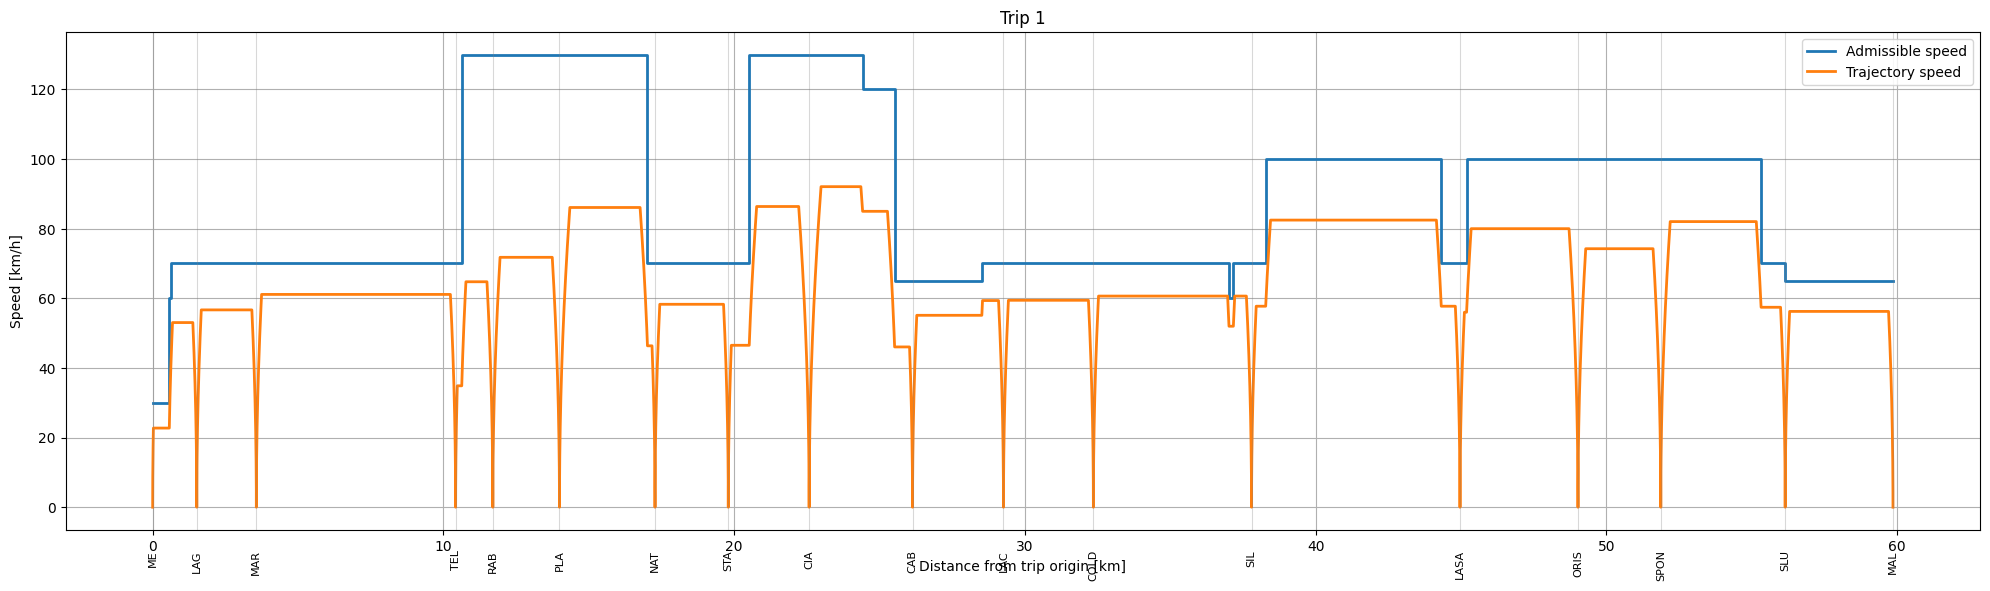

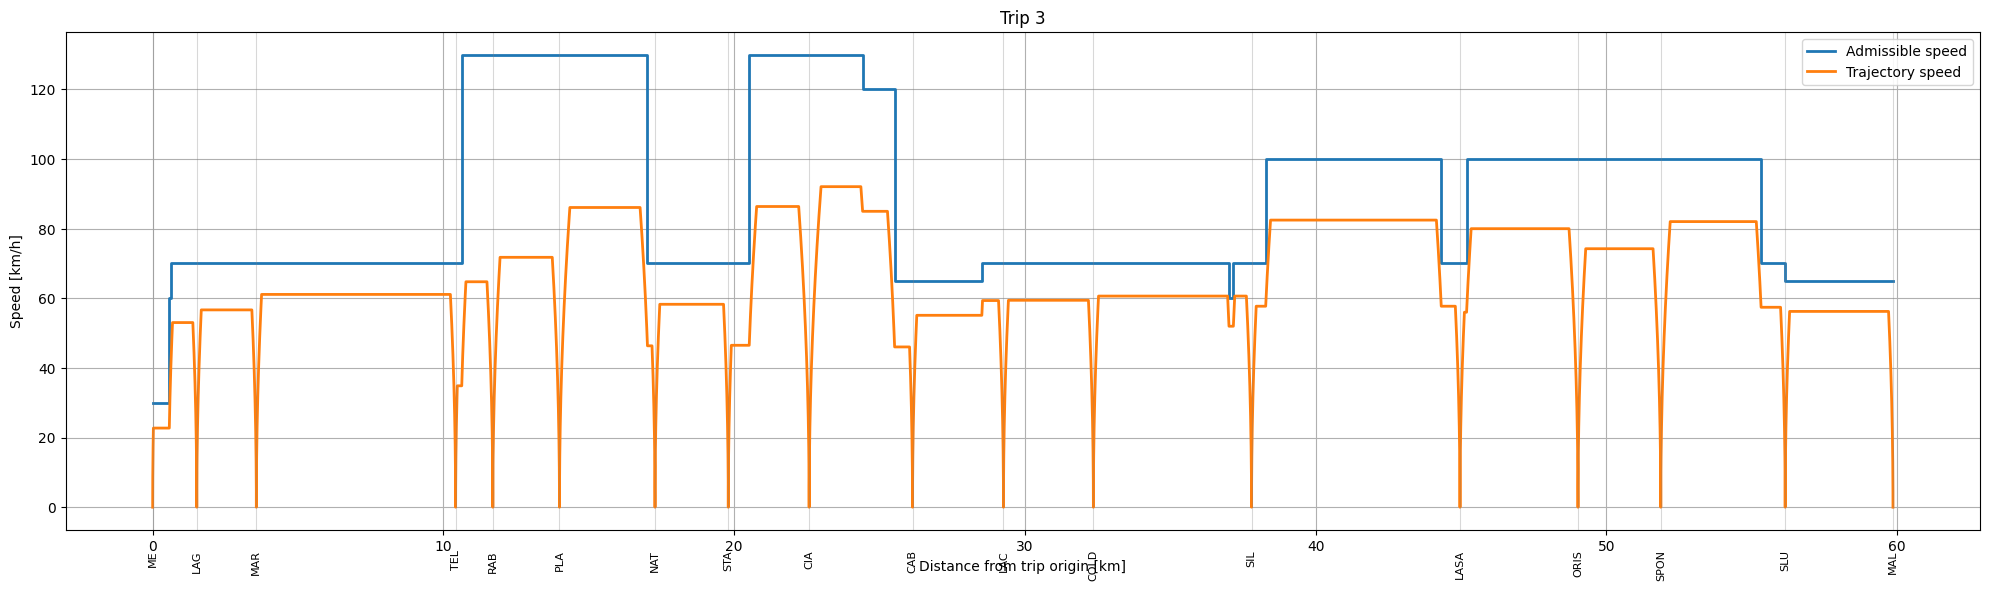

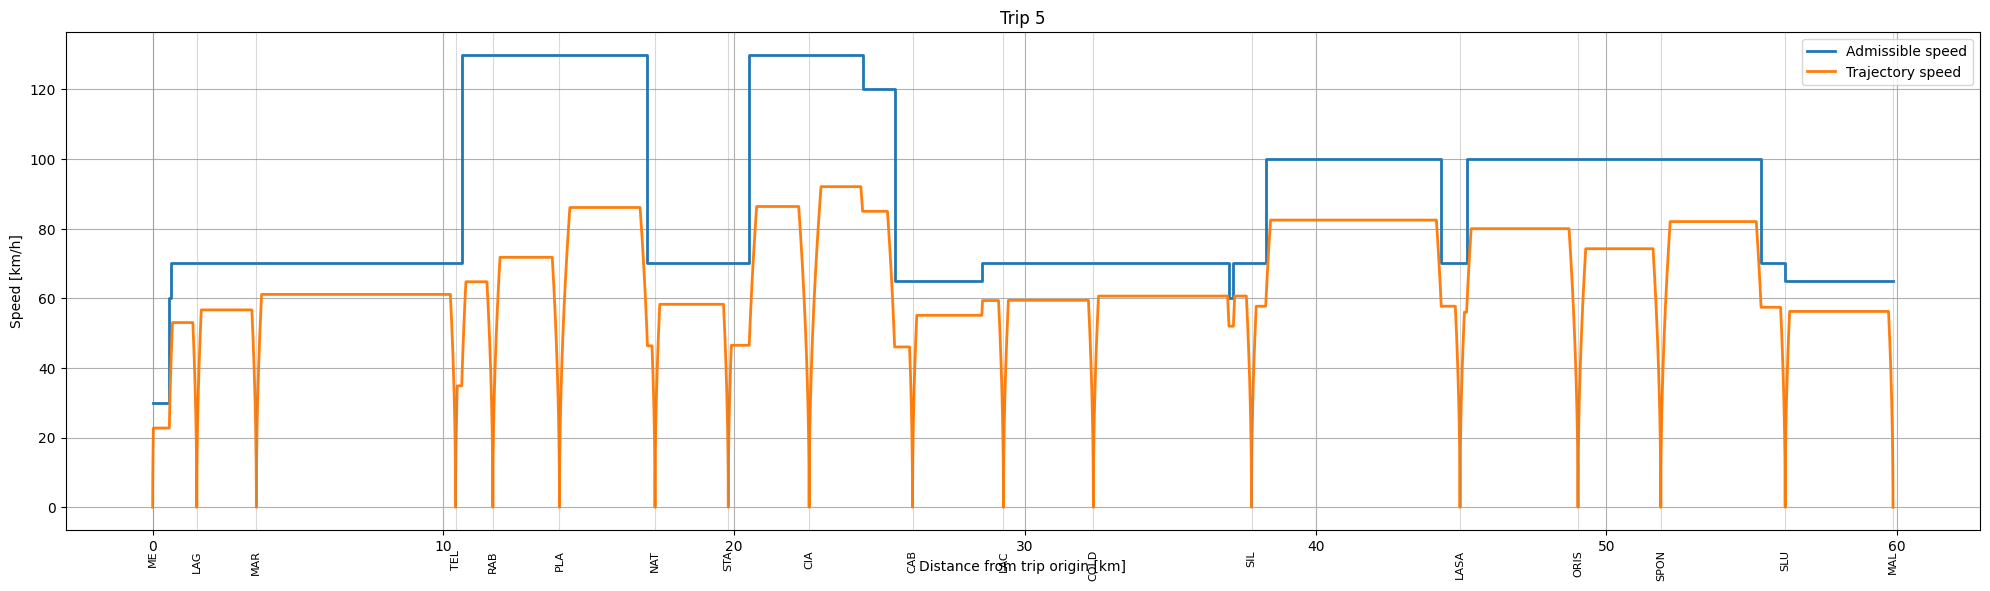

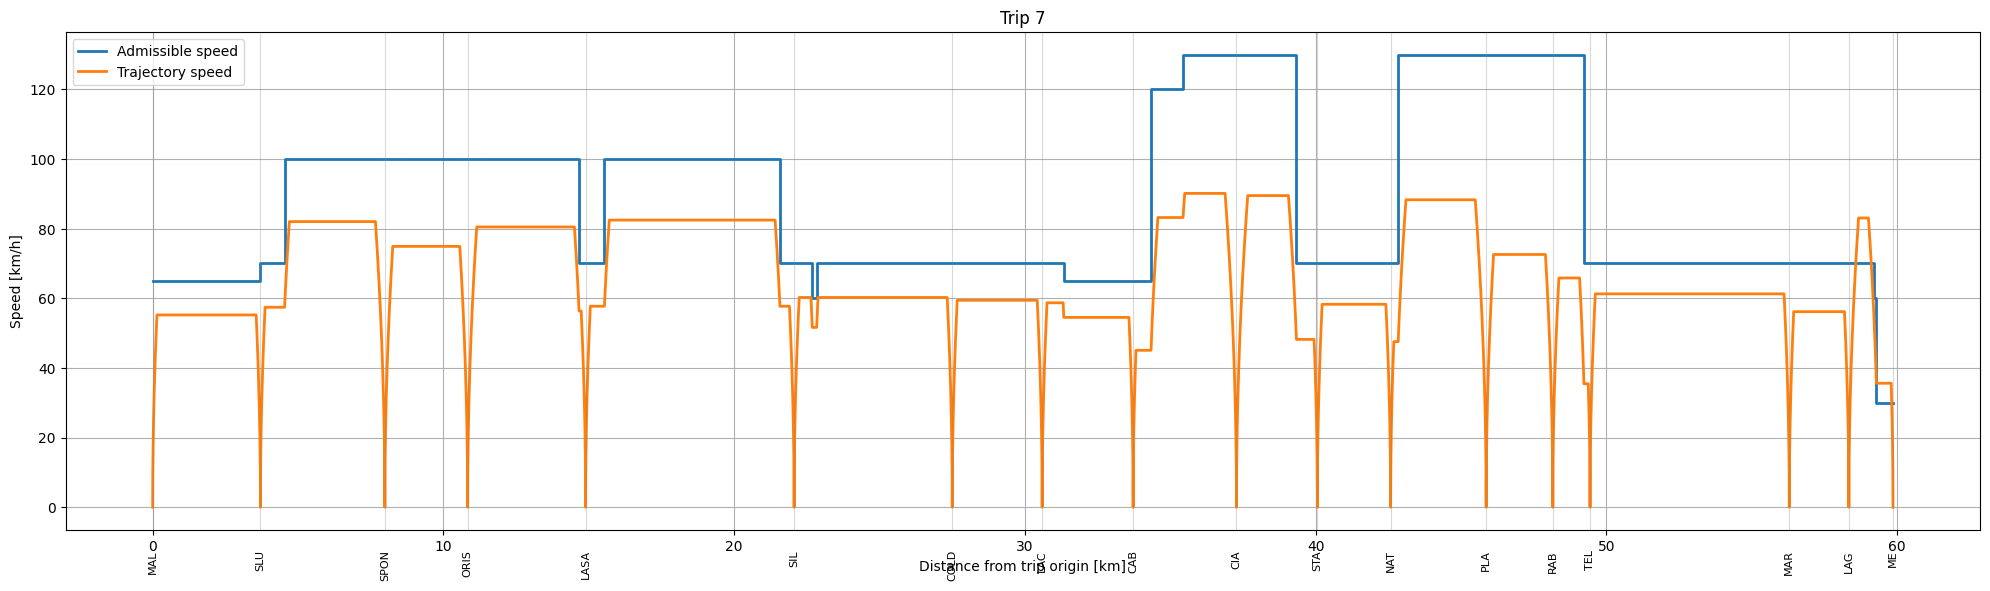

In [10]:
#for trip_id in [1, 2, 38, 36]:
for trip_id in [1, 3, 5, 7]:

    s_all = []
    v_all = []

    speed_limit_x = []
    speed_limit_y = []

    offset = 0

    for (start_id, _, start_dep), (end_id, end_arr, _) in zip(
            trip_data[trip_id][:-1],
            trip_data[trip_id][1:]):

        t, v, s = trajectory_result_sections[(trip_id, start_id, end_id)]

        route = rnode_path(routing_results[(start_id, end_id)])
        section_2_dist, section_2_speed = get_section_info(edgesDf, route)

        # trajectory
        s_all.extend(offset + np.asarray(s))
        v_all.extend(v)

        # speed limits
        local_pos = 0

        first = True

        for sec in sorted(section_2_dist.keys()):

            if first:
                speed_limit_x.append(offset)
                speed_limit_y.append(section_2_speed[sec])
                first = False

            local_pos += section_2_dist[sec]

            speed_limit_x.append(offset + local_pos)
            speed_limit_y.append(section_2_speed[sec])

            if sec < len(section_2_dist) - 1:
                speed_limit_x.append(offset + local_pos)
                speed_limit_y.append(section_2_speed[sec + 1])

        offset += s[-1]

    fig, ax = plt.subplots(figsize=(20, 6))

    ax.plot(
        speed_limit_x,
        speed_limit_y,
        linewidth=2,
        label="Admissible speed"
    )

    ax.plot(
        s_all,
        v_all,
        linewidth=2,
        label="Trajectory speed"
    )

    ax.set_xlabel("Distance from trip origin [km]")
    ax.set_ylabel("Speed [km/h]")
    ax.set_title(f"Trip {trip_id}")

    # --------------------------------------------------
    # Stop positions along the route
    # --------------------------------------------------

    stop_positions = [0.0]
    stop_names = [trip_data[trip_id][0][0]]

    cum_pos = 0.0

    for (start_id, _, _), (end_id, _, _) in zip(
            trip_data[trip_id][:-1],
            trip_data[trip_id][1:]):

        _, _, s = trajectory_result_sections[(trip_id, start_id, end_id)]

        cum_pos += s[-1]

        stop_positions.append(cum_pos)
        stop_names.append(end_id)

    # draw stops
    for x, stop in zip(stop_positions, stop_names):

        ax.axvline(
            x,
            color="grey",
            linewidth=0.8,
            alpha=0.3
        )

        ax.text(
            x,
            -0.04,
            stop,
            rotation=90,
            ha="center",
            va="top",
            fontsize=8,
            transform=ax.get_xaxis_transform()
        )

    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

In [11]:
def departure_at_station(trip, station_id):
    plattling_idx  = [t[0] for t in trip].index(station_id)
    return trip[plattling_idx][2]

def get_connected_trajectory(trip_id, trip_data, trajectory_result_sections):
    first_stop = trip_data[trip_id][0][0]
    second_stop = trip_data[trip_id][1][0]
    is_forward = nodesDf.loc[first_stop, "pk_rel"] < nodesDf.loc[second_stop, "pk_rel"]
    connected_path_t, connected_path_s = np.zeros(0), np.zeros(0)
    dep = departure_at_station(trip_data[trip_id], trip_data[trip_id][0][0])
    for (s, sa, sd), (e, ea, ed) in zip(trip_data[trip_id][:-1], trip_data[trip_id][1:]):
        t, v, sp = trajectory_result_sections[(trip_id, s, e)]
        connected_path_t = np.concatenate([
            connected_path_t,
            t + ((connected_path_t[-1] + (sd - sa).seconds / 3600)
                 if len(connected_path_t) > 0
                 else (dep.hour + dep.minute / 60 + dep.second / 3600))
        ])
        if is_forward:
            connected_path_s = np.concatenate([
                connected_path_s,
                sp + (connected_path_s[-1] if len(connected_path_s) > 0 else 0)
            ])
        else:
            if len(connected_path_s) == 0:
                connected_path_s = nodesDf.loc["MAL", "pk_rel"] - sp
            else:
                connected_path_s = np.concatenate([
                    connected_path_s,
                    connected_path_s[-1] - sp
                ])
    return connected_path_t, connected_path_s, is_forward

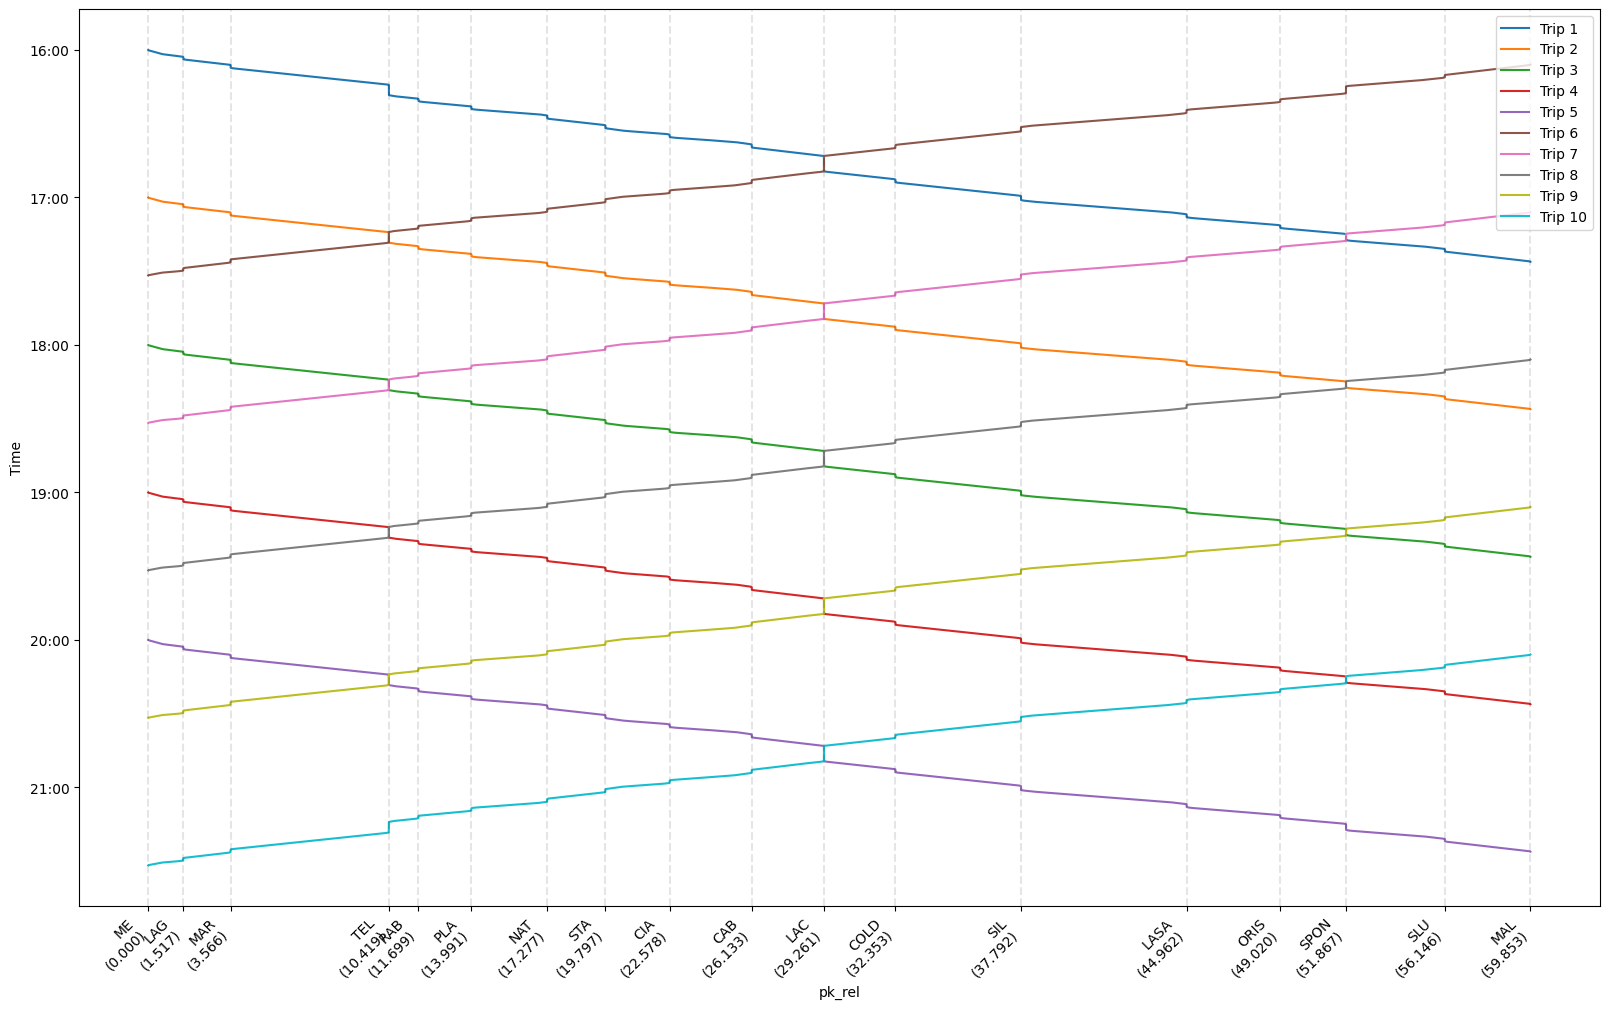

In [12]:
import matplotlib.ticker as mticker
plt.figure(figsize=(16, 10))

plt.gca().invert_yaxis()
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{int(y):02d}:{int((y % 1) * 60):02d}"))


pk_max = nodesDf["pk_rel"].iloc[-1]
full_trajectory = {}
for trip_id in selected_trips_sorted:
    connected_path_t, connected_path_s, is_forward = get_connected_trajectory(
        trip_id,
        trip_data,
        trajectory_result_sections
    )

    full_trajectory[trip_id] = (connected_path_t, connected_path_s, is_forward)

    plt.plot(connected_path_s, connected_path_t, label=f"Trip {trip_id}")

stops = nodesDf[(nodesDf["stop_slow"] == 1)& (nodesDf["y"] == 0)]

for x in stops["pk_rel"]:
    plt.axvline(color='black', x=x, linestyle="--", alpha=0.1)

plt.xticks(
    stops["pk_rel"],
    [f"{name}\n({pk:.3f})" for name, pk in zip(stops.index, stops["pk_rel"])],
    rotation=45,
    ha="right"
)

#plt.xlim(56.140,56.170)
plt.tight_layout()
plt.legend()
plt.xlabel("pk_rel")
plt.ylabel("Time")
plt.show()

In [15]:
#make chain boundary nodes valid in both directions, and split the single track into sections

nodes_up = build_route(nodesDf, edgesDf,'ME', 'MAL')
nodes_down = build_route(nodesDf, edgesDf, 'MAL', 'ME')

edges_up = list(zip(nodes_up[:-1], nodes_up[1:]))
edges_down = list(zip(nodes_down[:-1], nodes_down[1:]))

used_nodes = set(nodes_up) | set(nodes_down)

# undirected edge identity, so up/down traversals of the same physical track collapse together
used_edges = {frozenset(e) for e in edges_up} | {frozenset(e) for e in edges_down}

# degree of each used node, counting only used edges
edge_endpoints = pd.Series(
    [n for e in used_edges for n in e]
)
edge_counts = edge_endpoints.value_counts()

splitting_nodes = [
    n for n in used_nodes
    if nodesDf.loc[n, "y"] == 0 and edge_counts.get(n, 0) >= 3
]

single_track_boundaries = sorted(
    set(splitting_nodes) | {"ME", "MAL"},
    key=lambda n: nodesDf.loc[n, "pk_rel"]
)

sections = list(zip(single_track_boundaries[:-1], single_track_boundaries[1:]))

# --- assign "both" only to the boundary nodes themselves ---
nodesDf.loc[nodesDf.index.isin(single_track_boundaries), "valid_dir"] = "both"

# Reslice Trajectories

In [16]:
trajectory_resliced = {}


boundary_pk = { node: nodesDf.loc[node, "pk_rel"] for node in single_track_boundaries }

for trip_id, (t, s, is_forward) in full_trajectory.items():

    if is_forward:
        station_pairs = zip(
            single_track_boundaries[:-1],
            single_track_boundaries[1:]
        )
    else:
        station_pairs = zip(
            reversed(single_track_boundaries[1:]),
            reversed(single_track_boundaries[:-1])
        )

    for start_station, end_station in station_pairs:

        pk1 = boundary_pk[start_station]
        pk2 = boundary_pk[end_station]

        s_min = min(pk1, pk2)
        s_max = max(pk1, pk2)

        # Skip if trajectory never reaches the segment
        if s_max < s.min() or s_min > s.max():
            continue

        if s[0] < s[-1]:
            t_pk1 = np.interp(pk1, s, t)
            t_pk2 = np.interp(pk2, s, t)
        else:
            t_pk1 = np.interp(pk1, s[::-1], t[::-1])
            t_pk2 = np.interp(pk2, s[::-1], t[::-1])

        # Original samples inside the segment
        mask = (s >= s_min) & (s <= s_max)

        t_inside = t[mask]
        s_inside = s[mask]

        # Add exact boundary points
        t_slice = np.concatenate([
            [t_pk1],
            t_inside,
            [t_pk2]
        ])

        s_slice = np.concatenate([
            [pk1],
            s_inside,
            [pk2]
        ])

        # Sort by time (important because boundary points may be inserted
        # before/after the interior points)
        order = np.argsort(t_slice)

        t_slice = t_slice[order]
        s_slice = s_slice[order]

        trajectory_resliced[(trip_id, start_station, end_station)] = (
            t_slice,
            s_slice,
            is_forward
        )

# Blocks

## Functions

In [17]:
def plot_blocking_stairway_MAXSPEED(trajectory_entry, signal_pos, reaction_setup_time=30, release_time=5):
    t, s, is_forward = trajectory_entry
    blocking_section_ref = list(zip(signal_pos[:-1], signal_pos[1:]))
    # Ensure monotonic increasing s for interpolation and interval lookup
    if not is_forward:
        s_work = np.asarray(s[::-1])
        t_work = np.asarray(t[::-1])
        speed_col = "max_speed_dir_merano"
    else:
        s_work = np.asarray(s)
        t_work = np.asarray(t)
        speed_col = "max_speed_dir_malles"

    mask = np.concatenate(([True], np.diff(s_work) != 0))

    s_work = s_work[mask]
    t_work = t_work[mask]

    # Interpolation for actual signal crossing times
    f = interp1d(s_work,t_work,bounds_error=False,fill_value="extrapolate")

    signal_pos = np.asarray(signal_pos, dtype=float)

    signal_pos_shifted = signal_pos.copy()
    signal_pos_shifted[signal_pos_shifted == signal_pos.min()] += 0.001
    signal_pos_shifted[signal_pos_shifted == signal_pos.max()] -= 0.001

    signal_crossing_times = f(signal_pos_shifted)

    # Fill any extrapolated signal crossing times from the route endpoints.
    signal_crossing_times = np.where(
        np.isnan(signal_crossing_times),
        np.where(
            signal_pos <= np.min(s),
            t[-1],
            np.where(signal_pos >= np.max(s), t[0], np.nan),
        ),
        signal_crossing_times
    )

    pk_lookup = nodesDf["pk_rel"]

    edge_lengths = (edgesDf["node_to"].map(pk_lookup) - edgesDf["node_from"].map(pk_lookup)).abs().to_numpy()

    #edge_lengths = edgesDf["length"].to_numpy()

    edge_end_pos = np.cumsum(edge_lengths)
    edge_start_pos = np.concatenate(([0.0], edge_end_pos[:-1]))

    # Find the edge containing each signal
    edge_idx = np.searchsorted(edge_end_pos, signal_pos, side="right")
    edge_idx = np.clip(edge_idx, 0, len(edgesDf) - 1)

    # Get permitted speeds for those edges
    v_max = edgesDf[speed_col].to_numpy()[edge_idx]

    # Blocking times based on line speed
    signal_init_crossing_times = signal_crossing_times - 1.0 / v_max
    signal_release_crossing_times = signal_crossing_times + 0.2 / v_max

    init_time_by_pos = {
        float(pos): float(time)
        for pos, time in zip(signal_pos, signal_init_crossing_times)
    }

    release_time_by_pos = {
        float(pos): float(time)
        for pos, time in zip(signal_pos, signal_release_crossing_times)
    }

    blocking_times = {
        (s0, s1): (
            init_time_by_pos[float(s0)] - reaction_setup_time / 3600,
            release_time_by_pos[float(s1)] + release_time / 3600,
        )
        for (s0, s1) in blocking_section_ref
    }

    codes = []
    vertices = []

    for (s0, s1), (t0, t1) in blocking_times.items():
        codes += [Path.MOVETO, Path.LINETO, Path.LINETO, Path.LINETO, Path.CLOSEPOLY]
        vertices += [(s0, t0), (s1, t0), (s1, t1), (s0, t1), (0, 0)]

    path = Path(vertices, codes)
    patch = PathPatch(path, facecolor="none", edgecolor="k")
    ax.add_patch(patch)
    ax.plot(s, t)


    return blocking_times, release_time_by_pos, init_time_by_pos

In [18]:
def get_signal_nodes_on_route(route_nodes, is_forward):

    valid_dirs = ["malles", "both"] if is_forward else ["merano", "both"]

    signal_nodes = []

    for n in route_nodes:

        node = nodesDf.loc[n]

        if node["valid_dir"] not in valid_dirs:
            continue
        
        signal_nodes.append(n)

    return signal_nodes

In [19]:
def build_edge_occupations(blocking_times):
    edge_occupations = {}

    for trip_key, block_dict in blocking_times.items():

        _, start_station, end_station = trip_key

        route_nodes = build_route(nodesDf, edgesDf, start_station, end_station)

        route_edges = []

        for n1, n2 in zip(route_nodes[:-1], route_nodes[1:]):

            pk_a = nodesDf.loc[n1, "pk_rel"]
            pk_b = nodesDf.loc[n2, "pk_rel"]

            edge_pk_min = min(pk_a, pk_b)
            edge_pk_max = max(pk_a, pk_b)

            edge_name = (f"{n1}-{n2}"if pk_a <= pk_b else f"{n2}-{n1}")

            route_edges.append((edge_name,edge_pk_min,edge_pk_max))

        edge_occupations[trip_key] = {}

        for (pk0, pk1), (t_start, t_end) in block_dict.items():
            occupied_edges = []
            for edge_name, edge_min, edge_max in route_edges:
                block_min = min(pk0, pk1)
                block_max = max(pk0, pk1)
                overlaps = not (edge_max <= block_min or edge_min >= block_max)

                if overlaps:
                    occupied_edges.append(edge_name)

            edge_occupations[trip_key][tuple(occupied_edges)] = (t_start, t_end)
            
    return edge_occupations

In [20]:
def build_edge_events(edge_occupations):
    edge_events = defaultdict(list)

    for trip_key, block_dict in edge_occupations.items():

        trip_id, start_station, end_station = trip_key

        for edges, (t_in, t_out) in block_dict.items():

            for edge in edges:

                edge_events[edge].append(
                    {
                        "trip_id": trip_id,
                        "start_station": start_station,
                        "end_station": end_station,
                        "t_in": t_in,
                        "t_out": t_out,
                    }
                )
    
    return edge_events

In [21]:
def calculate_conflicts(edge_events):
    conflicts = []

    for edge, occupancies in edge_events.items():

        events = []

        for occ in occupancies:

            events.append(
                (
                    occ["t_in"],
                    "start",
                    occ,
                )
            )

            events.append(
                (
                    occ["t_out"],
                    "end",
                    occ,
                )
            )

        # important:
        # process "end" before "start" at equal timestamps
        events.sort(
            key=lambda x: (
                x[0],
                0 if x[1] == "end" else 1
            )
        )

        active = []

        for t, event_type, occ in events:

            if event_type == "start":

                for other in active:

                    conflict_start = max(
                        occ["t_in"],
                        other["t_in"]
                    )

                    conflict_end = min(
                        occ["t_out"],
                        other["t_out"]
                    )

                    conflicts.append(
                        {
                            "edge": edge,
                            "conflict_start": conflict_start,
                            "conflict_end": conflict_end,
                            "trip_1": (
                                occ["trip_id"],
                                occ["start_station"],
                                occ["end_station"],
                            ),
                            "trip_2": (
                                other["trip_id"],
                                other["start_station"],
                                other["end_station"],
                            ),
                        }
                    )

                active.append(occ)

            else:

                active.remove(occ)
                
    return conflicts

In [22]:
def hour_to_hms(t):

    h = int(t)
    m = int((t - h) * 60)
    s = int(round((t - h - m/60) * 3600))

    if s == 60:
        s = 0
        m += 1

    if m == 60:
        m = 0
        h += 1

    return f"{h:02d}:{m:02d}:{s:02d}"

In [23]:
def draw_conflicts(ax, conflicts, nodesDf):

    vertices = []
    codes = []

    for c in conflicts:

        node1, node2 = c["edge"].split("-")

        s0 = nodesDf.loc[node1, "pk_rel"]
        s1 = nodesDf.loc[node2, "pk_rel"]

        t0 = c["conflict_start"]
        t1 = c["conflict_end"]

        codes += [
            Path.MOVETO,
            Path.LINETO,
            Path.LINETO,
            Path.LINETO,
            Path.CLOSEPOLY,
        ]

        vertices += [
            (s0, t0),
            (s1, t0),
            (s1, t1),
            (s0, t1),
            (0, 0),
        ]

    if vertices:
        patch = PathPatch(
            Path(vertices, codes),
            facecolor="red",
            edgecolor="red",
            alpha=0.4,
            lw=0,
        )
        ax.add_patch(patch)

Text(0.5, 1.0, 'Conflicts')

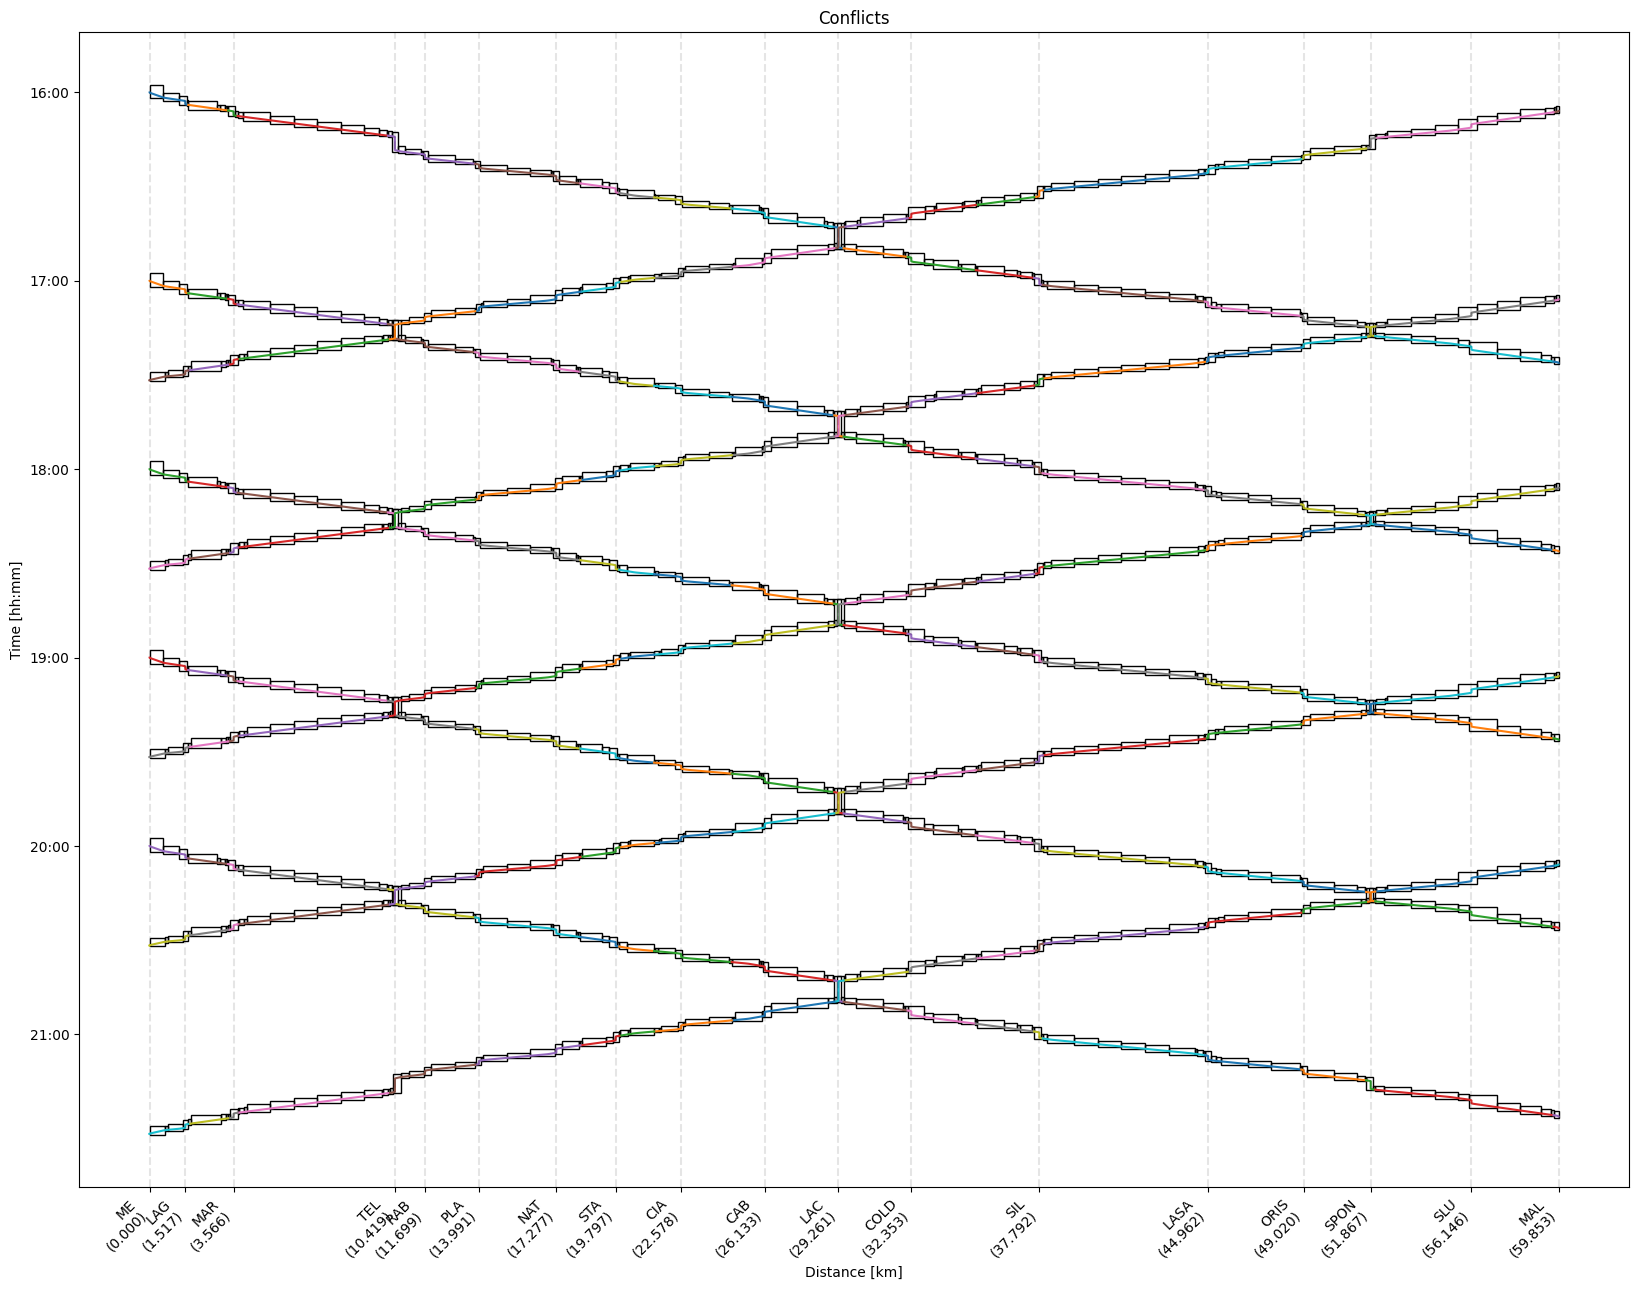

In [24]:
fig, ax = plt.subplots(figsize=(20, 15))

blocking_times = {}
release_time_by_pos = {}
init_time_by_pos = {}

a = "ME"
b = "MAL"

#to_plot = [20,21,22,23,24,25, 26, 27, 56,57,58,59,60,61, 62, 63,64,65]
#to_plot = range (1, 18)
to_plot = list(trip_data.keys())

pk_ref_min = min(nodesDf.loc[a, "pk_rel"], nodesDf.loc[b, "pk_rel"])
pk_ref_max = max(nodesDf.loc[a, "pk_rel"], nodesDf.loc[b, "pk_rel"])
signal_pos_ref = {}
signal_nodes = {}
for key, (t, s, is_forward) in trajectory_resliced.items():

    trip_id, start_station, end_station = key

    pk_start = nodesDf.loc[start_station, "pk_rel"]
    pk_end   = nodesDf.loc[end_station, "pk_rel"]

    if ((pk_start < pk_ref_min or pk_start > pk_ref_max)or(pk_end < pk_ref_min or pk_end > pk_ref_max)):
        continue

    if trip_id not in to_plot:
        continue

    route_nodes = build_route(nodesDf, edgesDf, start_station, end_station)

    signal_nodes[key] = get_signal_nodes_on_route(route_nodes,is_forward)

    signal_pos_ref[key] = [nodesDf.loc[n, "pk_rel"]for n in signal_nodes[key]]

    blocking_times[key], release_time_by_pos[key], init_time_by_pos[key] = plot_blocking_stairway_MAXSPEED(trajectory_resliced[key],signal_pos_ref[key])

edge_occupations = build_edge_occupations(blocking_times)
edge_events = build_edge_events(edge_occupations)
conflicts = calculate_conflicts(edge_events)
draw_conflicts(ax, conflicts, nodesDf)

for c in conflicts:
    print(c["edge"],hour_to_hms(c["conflict_start"]),hour_to_hms(c["conflict_end"]),c["trip_1"],c["trip_2"],)

stations_used = set(station for key in blocking_times.keys() for station in key[1:])
stops_used = nodesDf[(nodesDf['y'] == 0) & (nodesDf['stop_slow'] == 1) & (nodesDf['pk_rel'] >= min(nodesDf.loc[nodesDf.index.isin(stations_used), 'pk_rel'])) & (nodesDf['pk_rel'] <= max(nodesDf.loc[nodesDf.index.isin(stations_used), 'pk_rel']))]

for x in stops_used["pk_rel"]:
    plt.axvline(color="black",x=x,linestyle="--",alpha=0.1)

plt.xticks(stops_used["pk_rel"],[f"{name}\n({pk:.3f})"for name, pk in zip(stops_used.index, stops_used["pk_rel"])],rotation=45,ha="right")

plt.gca().invert_yaxis()
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{int(y):02d}:{int((y % 1) * 60):02d}"))

#plt.ylim(20,19)
#plt.xlim(44,49)
ax.set_xlabel("Distance [km]")
ax.set_ylabel("Time [hh:mm]")
ax.set_title("Conflicts")



In [27]:
import plotly.graph_objects as go
import plotly.io as pio
import numpy as np

# ==========================================================
# USER SETTINGS
# ==========================================================

TRIPS_TO_PLOT = set(to_plot)          # faster membership testing

SHOW_TRAJECTORIES = True
SHOW_BLOCKS = True
SHOW_CONFLICTS = True

# ==========================================================
# FIGURE
# ==========================================================

fig = go.Figure()

# We'll accumulate all shapes here and add them at once.
shapes = []

# ==========================================================
# TRAJECTORIES
# ==========================================================

if SHOW_TRAJECTORIES:

    for key, (t, s, is_forward) in trajectory_resliced.items():

        trip_id = int(key[0])

        if trip_id not in TRIPS_TO_PLOT:
            continue

        fig.add_trace(
            go.Scatter(
                x=s,
                y=t,
                mode="lines",
                name=f"{trip_id}: {key[1]}→{key[2]}",
                line=dict(width=2),
            )
        )

# ==========================================================
# BLOCK OCCUPATIONS
# ==========================================================

if SHOW_BLOCKS:

    for key, block_dict in blocking_times.items():

        trip_id = int(key[0])

        if trip_id not in TRIPS_TO_PLOT:
            continue

        for (s0, s1), (t0, t1) in block_dict.items():

            shapes.append(
                dict(
                    type="rect",
                    x0=min(s0, s1),
                    x1=max(s0, s1),
                    y0=t0,
                    y1=t1,
                    line=dict(color="black", width=1),
                    fillcolor="rgba(0,0,0,0)",
                )
            )

# ==========================================================
# CONFLICTS
# ==========================================================

if SHOW_CONFLICTS:

    marker_x = []
    marker_y = []
    marker_text = []

    for c in conflicts:

        trip1 = int(c["trip_1"][0])
        trip2 = int(c["trip_2"][0])

        if (
            trip1 not in TRIPS_TO_PLOT
            and trip2 not in TRIPS_TO_PLOT
        ):
            continue

        node1, node2 = c["edge"].split("-")

        pk0 = nodesDf.loc[node1, "pk_rel"]
        pk1 = nodesDf.loc[node2, "pk_rel"]

        shapes.append(
            dict(
                type="rect",
                x0=min(pk0, pk1),
                x1=max(pk0, pk1),
                y0=c["conflict_start"],
                y1=c["conflict_end"],
                line=dict(color="red", width=2),
                fillcolor="rgba(255,0,0,0.4)",
            )
        )

        marker_x.append((pk0 + pk1) / 2)
        marker_y.append((c["conflict_start"] + c["conflict_end"]) / 2)

        marker_text.append(
            "<br>".join([
                f"Edge: {c['edge']}",
                f"Trip 1: {c['trip_1']}",
                f"Trip 2: {c['trip_2']}",
                f"Start: {hour_to_hms(c['conflict_start'])} h",
                f"End: {hour_to_hms(c['conflict_end'])} h",
            ])
        )

    # Single trace for all conflict markers
    fig.add_trace(
        go.Scatter(
            x=marker_x,
            y=marker_y,
            mode="markers",
            marker=dict(
                color="red",
                size=6,
            ),
            text=marker_text,
            hovertemplate="%{text}<extra></extra>",
            showlegend=False,
        )
    )

# ==========================================================
# STATION LINES
# ==========================================================

stations = nodesDf[
    (nodesDf["stop_slow"] == 1)
    & (nodesDf["y"] == 0)
]

for _, row in stations.iterrows():

    shapes.append(
        dict(
            type="line",
            x0=row["pk_rel"],
            x1=row["pk_rel"],
            y0=0,
            y1=1,
            yref="paper",
            line=dict(
                dash="dash",
                color="black",
                width=1,
            ),
            opacity=0.15,
        )
    )

    fig.add_annotation(
        x=row["pk_rel"],
        y=1,
        yref="paper",
        text=f"{row.name}<br>{row['pk_rel']:.3f}",
        showarrow=False,
        textangle=-90,
        yshift=40,
        font=dict(size=9),
    )

# Add all shapes in one shot
fig.update_layout(shapes=shapes)

# ==========================================================
# LAYOUT
# ==========================================================

fig.update_layout(
    title=f"Scenario {scenario}: Trajectories, Blocks and Conflicts",
    width=1800,
    height=900,
    xaxis_title="pk_rel [km]",
    yaxis_title="Time [hh:mm]",
)

# ==========================================================
# TIME AXIS
# ==========================================================

all_times = []

for t, _, _ in trajectory_resliced.values():
    all_times.extend([np.min(t), np.max(t)])

for trip_blocks in blocking_times.values():
    for _, (t0, t1) in trip_blocks.items():
        all_times.extend([t0, t1])

tmin = np.floor(min(all_times) * 4) / 4
tmax = np.ceil(max(all_times) * 4) / 4

tickvals = np.arange(tmin, tmax + 0.001, 1 / 12)
ticktext = [hour_to_hms(t)[:5] for t in tickvals]

fig.update_yaxes(
    autorange="reversed",
    tickmode="array",
    tickvals=tickvals,
    ticktext=ticktext,
)

# ==========================================================
# OUTPUT
# ==========================================================

pio.write_html(
    fig,
    f"conflicts{scenario}.html",
    auto_open=True,
    config={
        "scrollZoom": True,
        "displayModeBar": True,
    },
)

# Headways

In [29]:
def get_min_headways(selected_trips_sorted, trip_id_2_blocking_times, trip_direction):
    trip_ids_2_critical_blocks = {}
    trip_ids_2_shifts = {}
    trip_ids_2_min_headways = {}
    
    for trip1, trip2 in zip(selected_trips_sorted[:-1], selected_trips_sorted[1:]):
        same_direction = (trip_direction[trip1] == trip_direction[trip2])
        min_shift = np.inf
        critical_block = None
        
        if same_direction:
            # Same logic as before: trip2 must wait for trip1 to clear each block
            for block_idx, (b1, b2) in enumerate(
                zip(trip_id_2_blocking_times[trip1], trip_id_2_blocking_times[trip2])
            ):
                
                init1, release1 = min(b1), max(b1)
                init2, release2 = min(b2), max(b2)
                shift = init2 - release1
                if shift < min_shift:
                    min_shift = shift
                    critical_block = block_idx
        else:
            # Opposite direction: blocks must not overlap in time
            # For each block, required shift = release1 - init2 (push trip2 after trip1 clears)
            for block_idx1, b1 in enumerate(trip_id_2_blocking_times[trip1]):

                init1, release1 = min(b1), max(b1)

                for block_idx2, b2 in enumerate(trip_id_2_blocking_times[trip2]):

                    init2, release2 = min(b2), max(b2)

                    shift = init2 - release1

                    if shift < min_shift:
                        min_shift = shift
                        critical_blocks = (block_idx1, block_idx2)

        trip_ids_2_critical_blocks[(trip1, trip2)] = critical_block
        trip_ids_2_shifts[(trip1, trip2)] = min_shift
        ref1 = (max if not same_direction else min)(trajectory_resliced[trip1][0])
        trip_ids_2_min_headways[(trip1, trip2)] = (min(trajectory_resliced[trip2][0]) - ref1 - min_shift) * 3600
    
    return trip_ids_2_min_headways, trip_ids_2_shifts, trip_ids_2_critical_blocks

In [30]:
def get_compressed_timetable(trip_id_2_blocking_times, trip_ids_2_shifts, trajectory_resliced):

    trip_id_2_blocking_times_compressed = {}
    trajectory_resliced_compressed = {}

    cumulative_shifts = np.cumsum(list(trip_ids_2_shifts.values()))

    for idx, trip_id in enumerate(trip_id_2_blocking_times):

        if idx == 0:
            # Reference train: no shift
            trip_id_2_blocking_times_compressed[trip_id] = trip_id_2_blocking_times[trip_id]
            trajectory_resliced_compressed[trip_id] = trajectory_resliced[trip_id]
            continue

        shift = cumulative_shifts[idx - 1]

        # Compress blocking times
        trip_id_2_blocking_times_compressed[trip_id] = [
            (t0 - shift, t1 - shift)
            for t0, t1 in trip_id_2_blocking_times[trip_id]
        ]

        # Compress trajectory
        times, positions, direction = trajectory_resliced[trip_id]

        trajectory_resliced_compressed[trip_id] = (
            times - shift,
            positions,
            direction,
        )

    return trip_id_2_blocking_times_compressed, trajectory_resliced_compressed

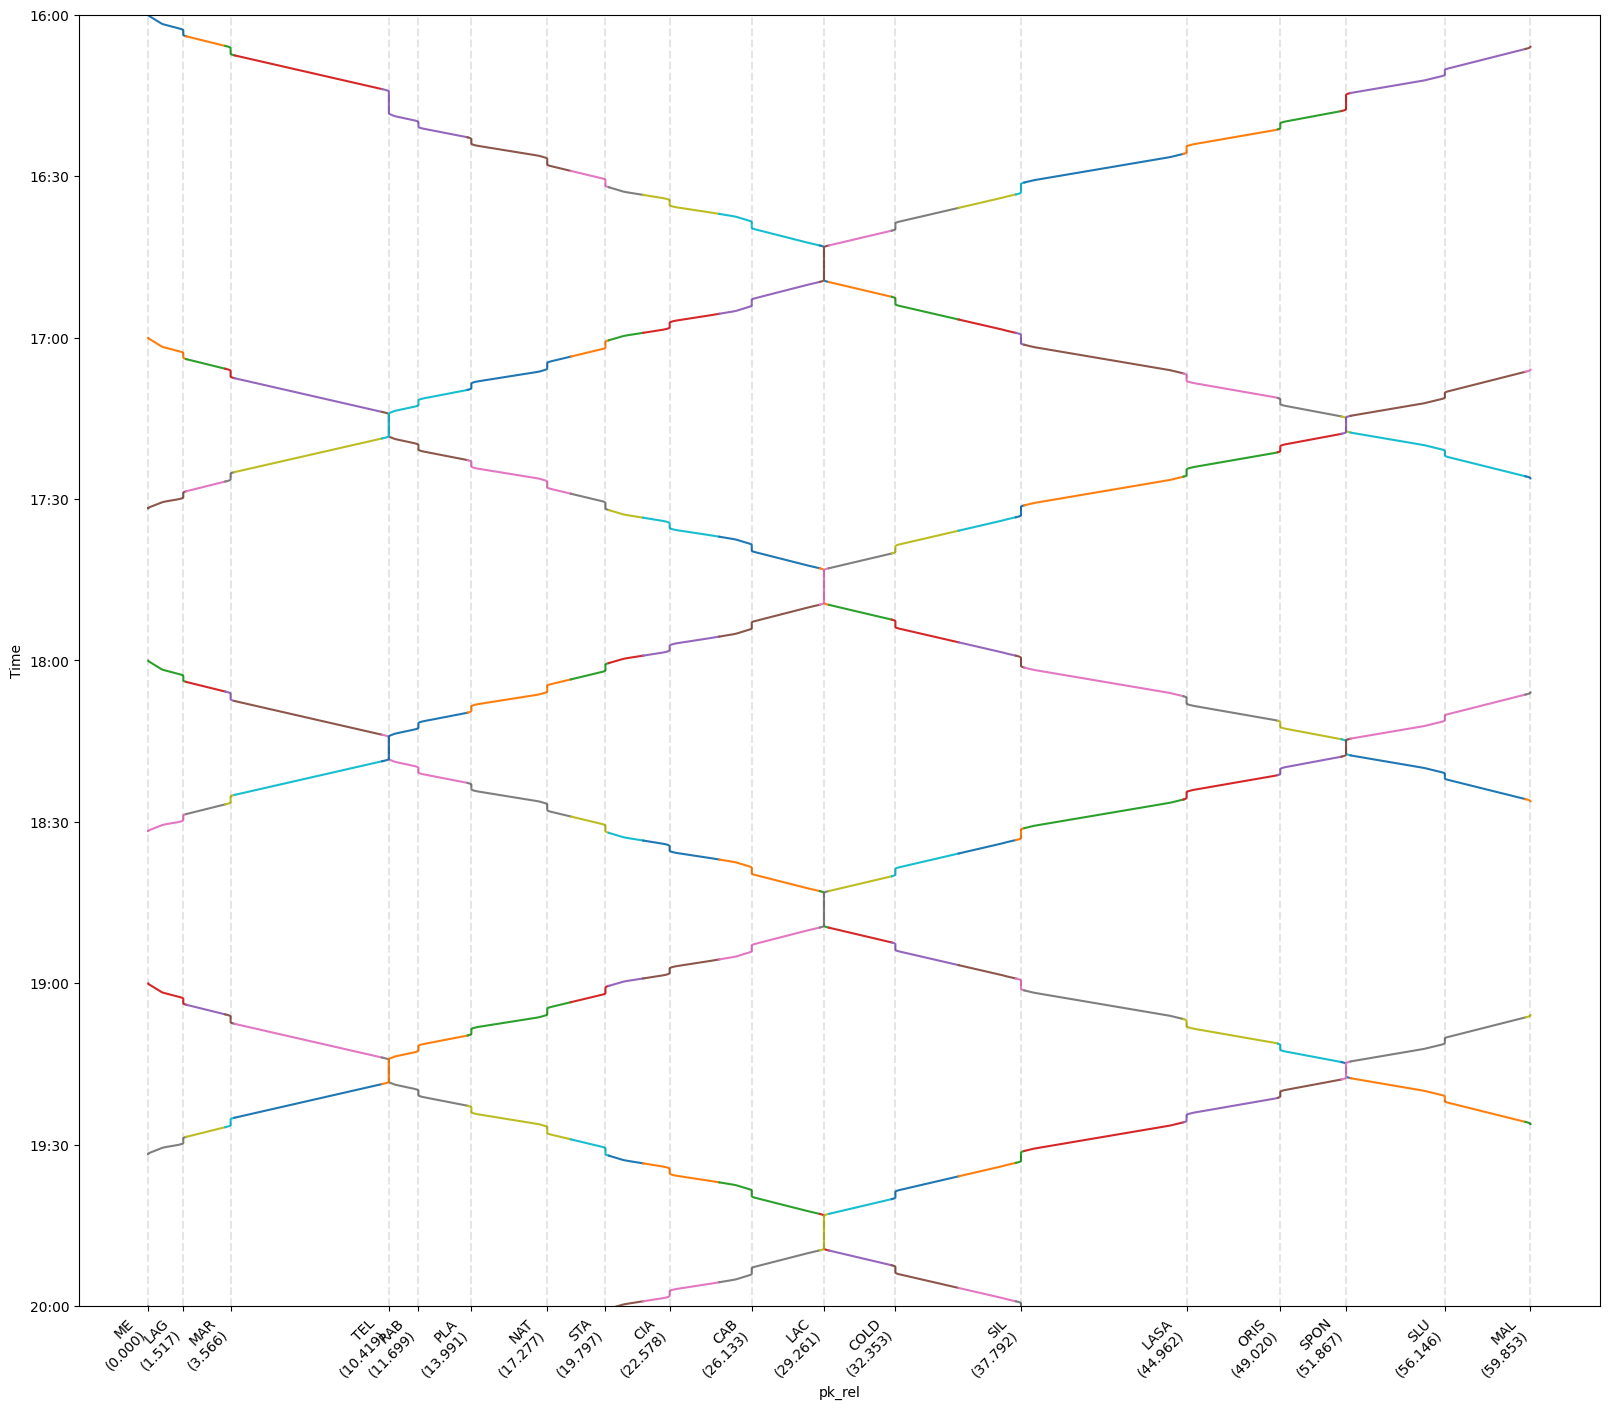

In [31]:
plt.figure(figsize=(16, 14))
for trip_id in selected_trips_sorted:
    for start, end in zip(single_track_boundaries[:-1], single_track_boundaries[1:]):
        first_stop = trip_data[trip_id][0][0]
        second_stop = trip_data[trip_id][1][0]
        is_forward = nodesDf.loc[first_stop, "pk_rel"] < nodesDf.loc[second_stop, "pk_rel"]

        if is_forward:
            key = (trip_id, start, end)
        else:
            key = (trip_id, end, start)

        plt.plot(trajectory_resliced[(key)][1], trajectory_resliced[(key)][0], label=f"Trip {trip_id}")

stops = nodesDf[(nodesDf["stop_slow"] == 1)& (nodesDf["y"] == 0)]

for x in stops["pk_rel"]:
    plt.axvline(color='black', x=x, linestyle="--", alpha=0.1)

plt.xticks(
    stops["pk_rel"],
    [f"{name}\n({pk:.3f})" for name, pk in zip(stops.index, stops["pk_rel"])],
    rotation=45,
    ha="right"
)

plt.gca().invert_yaxis()
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{int(y):02d}:{int((y % 1) * 60):02d}"))
plt.ylim(20,16)


plt.tight_layout()
plt.xlabel("pk_rel")
plt.ylabel("Time")
plt.show()

In [32]:
trip_key_2_blocking_times = {}
selected_keys_sorted = {}
trip_direction = {}
trajectory_resliced_sections = {}

for section in sections:
    start, end = section
    section_keys = [k for k in blocking_times if (k[1], k[2]) == (start, end) or (k[1], k[2]) == (end, start)]
    trip_key_2_blocking_times[section] = {k: list(blocking_times[k].values()) for k in section_keys}
    selected_keys_sorted[section] = sorted(section_keys, key=lambda k: k[0])
    trip_direction[section] = {k: 0 if trip_data[k[0]][0][0] == "ME" else 1 for k in section_keys}
    trajectory_resliced_sections[section] = {k: trajectory_resliced[k] for k in section_keys}

keys_2_min_headways = {}
trip_ids_2_shifts = {}
trip_ids_2_critical_blocks = {}
trip_key_2_blocking_times_compressed = {}
trajectory_resliced_compressed = {}

for section in sections:
    keys_2_min_headways[section], trip_ids_2_shifts[section], trip_ids_2_critical_blocks[section] = get_min_headways(selected_keys_sorted[section], trip_key_2_blocking_times[section], trip_direction[section])
    trip_key_2_blocking_times_compressed[section], trajectory_resliced_compressed[section] = get_compressed_timetable (trip_key_2_blocking_times[section], trip_ids_2_shifts[section], trajectory_resliced_sections[section])

In [33]:
def visualize_blocking_stairway_single_train(ax, blocking_section_pos, blocking_times, colors=None):     
    if colors is None:
        colors = ['none'] * len(blocking_section_pos)
    for bt, bs, color in zip(blocking_times, blocking_section_pos, colors):
        codes = []
        vertices = []
        codes = [Path.MOVETO] + [Path.LINETO] * 3 + [Path.CLOSEPOLY]
        vertices = [(bs[0], bt[0]), (bs[1], bt[0]), (bs[1], bt[1]), (bs[0], bt[1]), (0, 0)]
    
        path = Path(vertices, codes)
        pathpatch = PathPatch(path, facecolor=color, hatch="/")
    
    
        ax.add_patch(pathpatch)
        ax.autoscale_view()

In [34]:
signal_pos_ref = {}
blocking_section_ref = {}
directions = (0, 1)

for section in sections:
    signal_pos_ref[section] = {}
    blocking_section_ref[section] = {}

    pk_start = nodesDf.loc[section[0], "pk_rel"]
    pk_end   = nodesDf.loc[section[1], "pk_rel"]

    pk_min = min(pk_start, pk_end)
    pk_max = max(pk_start, pk_end)

    for d in directions:
        if d == 0:
            mask = ((nodesDf["y"] == 0) &nodesDf["valid_dir"].isin(["malles", "both"]) &nodesDf["pk_rel"].between(pk_min, pk_max))
            signal_pos_ref[section][d] = (nodesDf.loc[mask, "pk_rel"].drop_duplicates().sort_values().tolist())
            blocking_section_ref[section][d] = list(zip(np.asarray(signal_pos_ref[section][d][:-1]), signal_pos_ref[section][d][1:]))#signal positions
        else: 
            mask = ((nodesDf["y"] == 0) &nodesDf["valid_dir"].isin(["merano", "both"]) &nodesDf["pk_rel"].between(pk_min, pk_max))
            signal_pos_ref[section][d] = (nodesDf.loc[mask, "pk_rel"].drop_duplicates().sort_values(ascending=False).tolist())
            blocking_section_ref[section][d] = list(zip(np.asarray(signal_pos_ref[section][d][:-1]), signal_pos_ref[section][d][1:]))#signal positions


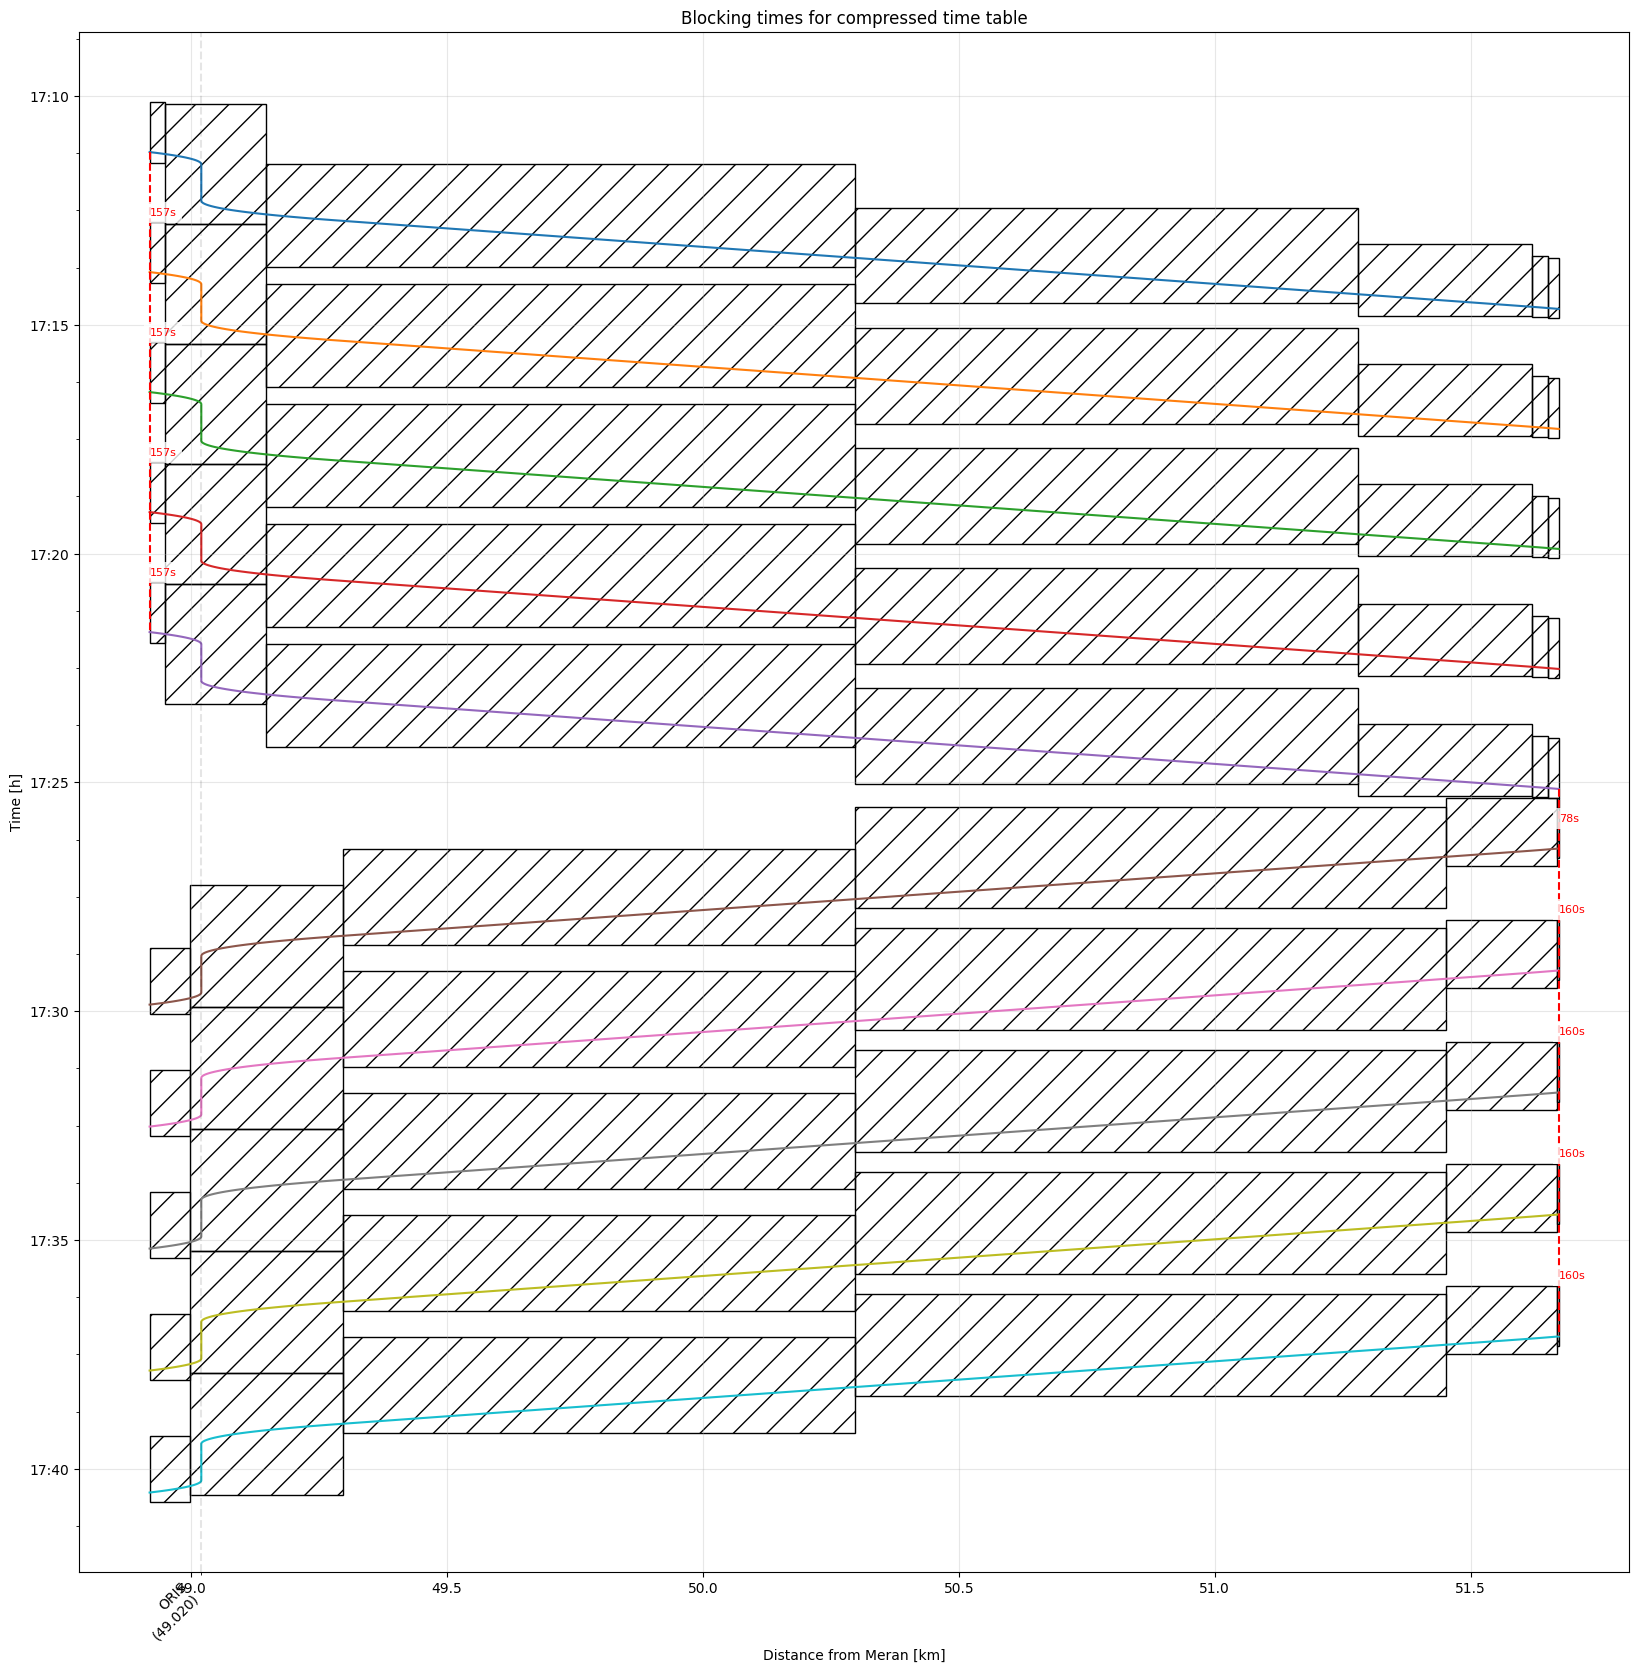

In [35]:
# visualize compressed timetable
fig, ax = plt.subplots(figsize=(20, 20))


ax.set_title("Blocking times for compressed time table")
ax.set_xlabel("Distance from Meran [km]")
ax.set_ylabel("Time [h]")

yticks = np.arange(0, 24 + 5/60, 5/60)  # ogni 5 minuti

ax.set_yticks(yticks,labels=[f"{int(h):02d}:{int(round((h % 1) * 60)):02d}"for h in yticks])

section = ('Dev_ORIS_01', 'Dev_SPON_01')

for key in selected_keys_sorted[section]:
    pk1 = float(str(nodesDf.loc[key[1], "pk_rel"]).replace(",", "."))
    pk2 = float(str(nodesDf.loc[key[2], "pk_rel"]).replace(",", "."))
    d = 0 if pk1 < pk2 else 1
    visualize_blocking_stairway_single_train(ax,blocking_section_ref[section][d],trip_key_2_blocking_times_compressed[section][key],colors=None)
    s, t = trajectory_resliced_compressed[section][(key)][1], trajectory_resliced_compressed[section][(key)][0]
    ax.plot(s, t)

# Draw critical headway lines
for (k1, k2), required_hw in keys_2_min_headways[section].items():

    t1, s1, dir1 = trajectory_resliced_compressed[section][k1]
    t2, s2, dir2 = trajectory_resliced_compressed[section][k2]

    if dir1 == dir2:
        # Same direction: compare departures (= earliest point on trajectory)
        i1 = np.argmin(t1)
        i2 = np.argmin(t2)

        time1, pos1 = t1[i1], s1[i1]
        time2, pos2 = t2[i2], s2[i2]

    else:
        # Opposite directions: use minimum positive boundary separation
        events1 = {
            "start": (t1[0],  s1[0]),
            "end":   (t1[-1], s1[-1]),
        }

        events2 = {
            "start": (t2[0],  s2[0]),
            "end":   (t2[-1], s2[-1]),
        }

        candidates = []

        for time1, pos1 in events1.values():
            for time2, pos2 in events2.values():
                dt = time2 - time1
                if dt >= 0:
                    candidates.append((dt, time1, pos1, time2, pos2))

        if not candidates:
            continue

        _, time1, pos1, time2, pos2 = min(candidates, key=lambda x: x[0])

    # Draw headway line
    x = 0.5 * (pos1 + pos2)

    ax.plot([x, x], [time1, time2], "r--", lw=1.5)

    ax.text(
        x,
        0.5 * (time1 + time2),
        f"{required_hw:.0f}s",
        color="red",
        fontsize=8,
        ha="left",
        va="center",
        bbox=dict(fc="white", ec="none", alpha=0.8),
    )

stops = nodesDf[nodesDf["stop_slow"] == 1]

stations_used = set(station for key in selected_keys_sorted[section] for station in key[1:])
stops_used = nodesDf[(nodesDf['stop_slow'] == 1) & (nodesDf['pk_rel'] >= min(nodesDf.loc[nodesDf.index.isin(stations_used), 'pk_rel'])) & (nodesDf['pk_rel'] <= max(nodesDf.loc[nodesDf.index.isin(stations_used), 'pk_rel']))]


for x in stops_used["pk_rel"]:
    plt.axvline(color="black",x=x,linestyle="--",alpha=0.1)

ax = plt.gca()

# Keep automatic major ticks
ax.minorticks_on()

# Add station positions as minor ticks
ax.set_xticks(stops_used["pk_rel"], minor=True)

ax.set_xticklabels([f"{name}\n({pk:.3f})" for name, pk in zip(stops_used.index, stops_used["pk_rel"])],minor=True,rotation=45,ha="right")
plt.grid(True, which="major", axis="both", alpha=0.3)
plt.gca().invert_yaxis()
plt.show()

In [36]:
trip_type_map = {
    1: "fast up",
    2: "slow up",
    3: "fast down",
    4: "slow down",
}

In [37]:
expanded_trip_to_type = {
    1: 1,
    2: 1,
    3: 2,
    4: 1,
    5: 3,
    6: 1,
    7: 4,
    8: 2,
    9: 2,
    10: 3,
    11: 2,
    12: 4,
    13: 3,
    14: 3,
    15: 4,
    16: 4,
    17: 1,
}

In [38]:
all_min_headways = {
    (
        section,
        trip_type_map[expanded_trip_to_type[int(trip1[0])]],
        trip_type_map[expanded_trip_to_type[int(trip2[0])]],
    ): float(val)

    for section, pair_dict in keys_2_min_headways.items()
    for (trip1, trip2), val in pair_dict.items()
}

In [39]:
extra_entries = {}

for (chain, cat1, cat2), value in all_min_headways.items():

    start, end = chain

    # Upper terminal
    if start == "ME":
        extra_entries[(("ME_side", end), cat1, cat2)] = value

    # Lower terminal
    if end == "MAL":
        extra_entries[((start, "MAL_side"), cat1, cat2)] = value

all_min_headways.update(extra_entries)

In [40]:
'''labels = ["fast up", "slow up", "fast down", "slow down"]

matrices = {}

for (section, frm, to), val in all_min_headways.items():

    if section not in matrices:
        matrices[section] = pd.DataFrame(
            np.nan,
            index=labels,
            columns=labels
        )

    matrices[section].loc[frm, to] = float(val)

with pd.ExcelWriter(f"all_min_headways{scenario}.xlsx") as writer:
    for section, df in matrices.items():
        df.to_excel(writer, sheet_name=f"{section[0]}_{section[1]}")'''

'labels = ["fast up", "slow up", "fast down", "slow down"]\n\nmatrices = {}\n\nfor (section, frm, to), val in all_min_headways.items():\n\n    if section not in matrices:\n        matrices[section] = pd.DataFrame(\n            np.nan,\n            index=labels,\n            columns=labels\n        )\n\n    matrices[section].loc[frm, to] = float(val)\n\nwith pd.ExcelWriter(f"all_min_headways{scenario}.xlsx") as writer:\n    for section, df in matrices.items():\n        df.to_excel(writer, sheet_name=f"{section[0]}_{section[1]}")'

In [41]:
'''from pathlib import Path

save_path = Path.cwd() / f"all_min_headways{scenario}.npy"
np.save(save_path, all_min_headways, allow_pickle=True)'''

'from pathlib import Path\n\nsave_path = Path.cwd() / f"all_min_headways{scenario}.npy"\nnp.save(save_path, all_min_headways, allow_pickle=True)'